## Modelo  Multivariado

Los primeros modelos estadísticos abordados en este curso han sido modelos univariados, que se caracterizan por tener una sola medición en cada miembro de una muestra de individuos o en cada ejecución de un experimento repetido. Sin embargo, los conjuntos de datos son frecuentemente multivariados, con múltiples medidas para cada individuo o experimento. 

Existen igualmente modelos discretos y continuos y cada uno de ellos se puede abordar usando la misma regla de bayes para encontrar una distribución conjugada posterior. En este cuaderno revisaremos la distribución multinomial que sigue el mismo proceso de una distribución binomial con una mayor cantidad de resultados posibles. La distribución previa y la posterior provienen de la distribución  Dirichlet que en este caso es conjugada y que es una variación especial de la distribución Beta.

A partir de este cuaderno se usarán algunas librerias adicionales que permiten representar mejor los resultados.

En esta se usará el paquete [PyMC](https://docs.pymc.io), que se puede instalar en jupyter usando este comando !pip install pymc3. 


### Distribución Multinomial

Para datos categóricos que se producen a partir de unas observaciones $y$,  se pueden obtener $k$ posibles resultados, para unas variables $(y_{1},...,y_{k}$ estas siguen una distribución binomial con parámetros $Mult(n,\theta_{1},...,\theta_{k})$ donde $\sum_{i=1}^{k}y_{i}=n$:

$$p(y_{1},...,y_{k}\mid \theta_{1},...,\theta_{k},n) = \frac{\Gamma (n+1)}{\prod_{i=1}^{k}\Gamma (y_{i}+1)} \prod_{j=1}^{k} \theta_{j}^{y_{j}}$$
$$p(y_{1},...,y_{k}\mid \theta_{1},...,\theta_{k},n) \propto \prod_{j=1}^{k} \theta_{j}^{y_{j}}$$

Donde la suma de cada parámetro $\theta_{j}=1$ para $\mathbf{\theta}=(\theta_{1},...,\theta_{j})$, esta es la función likelihood en donde los datos dependen de los parámetros. 

### Distribución Dirichlet

Esta distribución es la versión multivariada de la distribución beta, se denota $Dir(\alpha_{1},...,\alpha_{k})$, es un escalar positivo $\alpha_{1}>0$. La función de densidad se calcula como:

$$p(\theta_{1},...,\theta_{k};\alpha_{1},...,\alpha_{k})=\frac{\Gamma(\sum_{i=1}^{k}\alpha_{i})}{\prod_{i=1}^{k}\Gamma(\alpha_{i})}\prod_{i=1}^{k}\theta_{i=1}^{\alpha_{i}-1}$$

$$p(\theta_{1},...,\theta_{k};\alpha_{1},...,\alpha_{k}) \propto \prod_{i=1}^{k}\theta_{i=1}^{\alpha_{i}-1}$$
  
La distribución prior es matemáticamente equivalente a una likelihood  resultante de la suma de cada parámetro $\alpha$ $\sum_{j=1}^{k}\alpha_{j}$ con $\alpha_{j}$ observaciones de la j-ésima categoría de resultado. Como en el binomio, hay varias distribuciones previas de Dirichlet no informativas plausibles. La densidad uniforme se obtiene con $\alpha_{1}=1$


En el siguiente código se puede observar las características de la función Dirichlet para parámetros $\theta_{1}, \theta_{2}, \theta{3}$ que corresponden a las esquinas de un triangulo. Cada punto tiene una probabilidad de aparecer, en la medida  en que $\alpha$ se incrementa, la distribución se concentra en el centro.

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import seaborn as sns
import numpy.random as npr
from math import gamma
from operator import mul
from functools import reduce
sns.set(style='white', font_scale=1.2, font='consolas')
%matplotlib inline
from scipy.optimize import brentq
plt.rc('font', size=12)

%config Inline.figure_formats = ['retina']

def plot_mesh(corners):
    """Subdivide the triangle into a triangular mesh and plot the original and subdivided triangles."""
    triangle = tri.Triangulation(corners[:, 0], corners[:, 1])

    refiner = tri.UniformTriRefiner(triangle)
    trimesh = refiner.refine_triangulation(subdiv=4)
    
    plt.figure(figsize=(6, 4))
    for i, mesh in enumerate((triangle, trimesh)):
        plt.subplot(1, 2, i+1)
        plt.triplot(mesh)
        plt.axis('off')
        plt.axis('equal')    
        
        
class Dirichlet:
    """Define the Dirichlet distribution with vector parameter alpha."""
    def __init__(self, alpha):
        
        self._alpha = np.array(alpha)
        self._coef = gamma(np.sum(self._alpha)) / reduce(mul, [gamma(a) for a in self._alpha])
    
    def pdf(self, x):
        """Returns pdf value for `x`. """
        return self._coef * reduce(mul, [xx ** (aa-1) for (xx, aa) in zip(x, self._alpha)])
        
        
class PlotDirichlet:
    """
    Plot the Dirichlet distribution as a contour plot on a 2-Simplex.
    """
    def __init__(self, corners):
        self._corners = corners
        self._triangle = tri.Triangulation(corners[:, 0], corners[:, 1])
        # Midpoints of triangle sides opposite of each corner
        self._midpoints = [(corners[(i+1) % 3] + corners[(i+2) % 3]) / 2.0 for i in range(3)]
        
    def xy2bc(self, xy, tol=1.e-3):
        """Map the x-y coordinates of the mesh vertices to the simplex coordinate space (aka barycentric coordinates).
        Here we use a simple method that uses vector algebra. For some values of alpha, calculation of the Dirichlet pdf 
        can become numerically unstable at the boundaries of the simplex so our conversion function will take an optional 
        tolerance that will avoid barycentric coordinate values directly on the simplex boundary.        
        """
        s = [(self._corners[i] - self._midpoints[i]).dot(xy - self._midpoints[i]) / 0.75 for i in range(3)]
        return np.clip(s, tol, 1.0-tol)
        
    def draw_pdf_contours(self, ax, dist, label=None, nlevels=200, subdiv=8, **kwargs):
        """Draw pdf contours for a Dirichlet distribution"""
        # Subdivide the triangle into a triangular mesh
        refiner = tri.UniformTriRefiner(self._triangle)
        trimesh = refiner.refine_triangulation(subdiv=subdiv)
        
        # convert to barycentric coordinates and compute probabilities of the given distribution 
        pvals = [dist.pdf(self.xy2bc(xy)) for xy in zip(trimesh.x, trimesh.y)]
    
        ax.tricontourf(trimesh, pvals, nlevels, **kwargs)
        #plt.axis('equal')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 0.75**0.5)
        ax.set_title(str(label))
        ax.axis('off') 
        return ax


findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas'

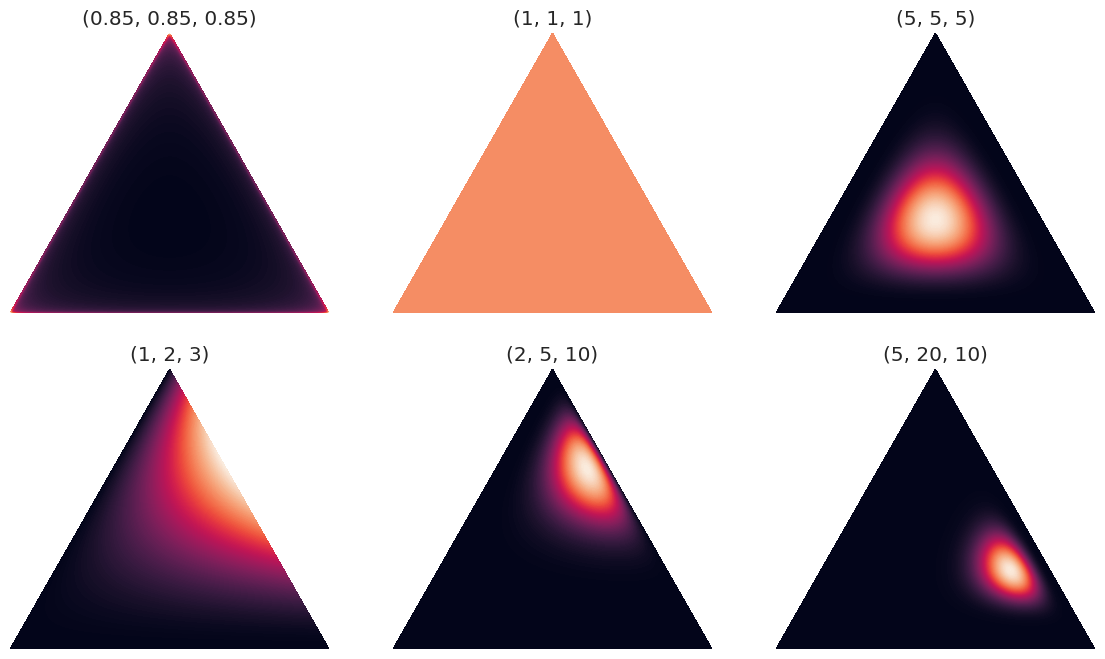

In [4]:
if __name__ == '__main__':
    corners = np.array([[0, 0], [1, 0], [0.5, 0.75**0.5]])
    plot_dirichlet = PlotDirichlet(corners)
   
    f, axes = plt.subplots(2, 3, figsize=(14, 8))
    ax = axes[0, 0]
    alpha = (0.85, 0.85, 0.85)
    dist = Dirichlet(alpha)
    ax = plot_dirichlet.draw_pdf_contours(ax, dist, alpha)

    ax = axes[0, 1]
    alpha = (1, 1, 1)
    dist = Dirichlet(alpha)
    ax = plot_dirichlet.draw_pdf_contours(ax, dist, alpha)

    ax = axes[0, 2]
    alpha = (5, 5, 5)
    dist = Dirichlet(alpha)
    ax = plot_dirichlet.draw_pdf_contours(ax, dist, alpha)

    ax = axes[1, 0]
    alpha = (1, 2, 3)
    dist = Dirichlet(alpha)
    ax = plot_dirichlet.draw_pdf_contours(ax, dist, alpha)

    ax = axes[1, 1]
    alpha = (2, 5, 10)
    dist = Dirichlet(alpha)
    ax = plot_dirichlet.draw_pdf_contours(ax, dist, alpha)

    ax = axes[1, 2]
    alpha = (5, 20, 10)
    dist = Dirichlet(alpha)
    ax = plot_dirichlet.draw_pdf_contours(ax, dist, alpha)



A continuación, $\textbf{Y}$ se refiere al conjunto  y normalmente se asume que cada $y_{i} \in \textbf{Y}$ se extrae iid de la misma distribución $f (y; \theta)$, donde $\theta$ parametriza la distribución likelihood. Cuando las personas dicen que están "siendo bayesianos", lo que esto suele significar es que están tratando a $\theta$ como una incógnita, pero postulando que $\theta$ sigue una distribución previa $f(\theta; \alpha)$, donde $\alpha$ parametriza la distribución previa (y a menudo se denomina hiperparámetro).

La distribución posterior $f(\theta \mid \textbf{Y})$ se obtiene con ayude de la distribución likelihood que ofrece la mutlinomial, y la ditribución prior que es con ayuda de la función diricthlet.

$$f(\theta\mid\textbf{Y})=\frac{f(\theta, \textbf{Y})}{f(\textbf{Y})}\propto f(\theta, \textbf{Y})=f(\theta, \alpha)\prod_{y_{i}\in \textbf{Y}} f(y_{i}\mid \theta)$$

Donde ka distribución marginal de los datos $$f(\textbf{Y})=\int f(\theta \mid \alpha) \prod_{y_{i}\in \textbf{Y}} f(y_{i}\mid \theta)=d\theta$$


### Distribución Posterior

$$\theta_{1},...,\theta_{k}\sim Dir(\alpha_{1},...,\alpha_{k})$$

$$y_{1},...,y_{k}\sim Mult(\theta_{1},...,\theta_{k})$$

$$f(\theta\mid\textbf{Y})=\prod_{j=1}^{k}\theta_{j}^{\alpha_{j}-1+\sum_{y_{i}\in \textbf{Y}}y_{i}^{j}}$$



### Ejemplo 

Se lanza un dado  122 veces donde $p$ representa la probabilidad de cada uno de los lados que es $1/6$. Los resultados de las veces que sale un número se almacenan en un vector $\textbf{Y}$. El objetivo de este ejercicio, es revisar si realmente la probabilidad de tener un valor entre uno y seis es la misma para todos o el dado está truncado o sesgado hacia un número especial.


In [4]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import arviz as az
y=np.asarray([20,21,17,19,17,28])
k=len(y)
p=1/k
n=y.sum()
print(n,p)


122 0.16666666666666666


<Axes: >

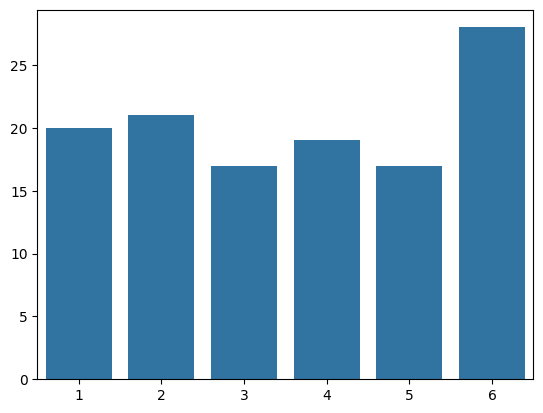

In [5]:
sns.barplot(x=np.arange(1,k+1),y=y)

Esta es una representación de los resultados, a primera vista se puede observar que realmente el número 6 aparece con mayor frecuencia. Ahora se desea estimar la probabilidad del lanzamiento del dado y también si existe un sesgo con respecto al valor número seis usando los datos observados y los posibles resultados. Para implementar la función Dirichlet se asume como información previa la que se obtiene de una distribución uniforme para indicar que todos los números tienen la misma posibilidad de aparecer.

In [6]:
with pm.Model() as dice_model:
    a=[1,3,0.5,2,7,10]
    theta=pm.Dirichlet("theta",a=a)
    six_bias=pm.Deterministic("six_bias", theta[k-1]-p)## Se usa esta función para determinar el sesgo hacia el valor número 6
    results=pm.Multinomial("results",n=n,p=theta,observed=y) ## Distribución Likelihood
    

In [7]:
with dice_model:
    dice_trace=pm.sample(draws=1000)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


/Users/andresmartinez/Dropbox/UExternado/EstadisticaBayesiana/Codigos/.venv/lib/python3.11/site-packages/rich/live.
py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


/Users/andresmartinez/Dropbox/UExternado/EstadisticaBayesiana/Codigos/.venv/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/traceplot.py:218: UserWarning: A valid var_name should be provided, found {'t'} expected from {'theta', 'six_bias'}
  warnings.warn(


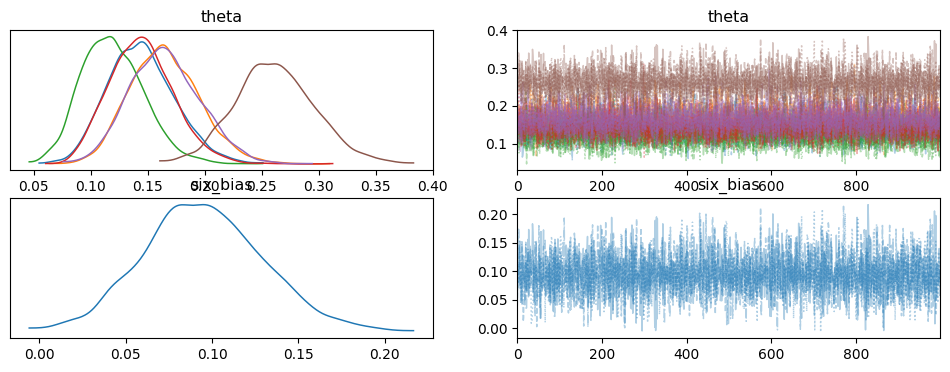

In [8]:
with dice_model:
    pm.plot_trace(dice_trace, combined=True,lines={"theta":p})

En esta gráfica se puede observar que uno de los parámetros $\theta$ se aleja de los demás y eso se puede observar en el sesgo de la siguiente gráfica. Luego se obtienen la función de densidad y los intervalos HPD para cada uno de los parámetros incluyendo el sesgo hacia el valor número seis.

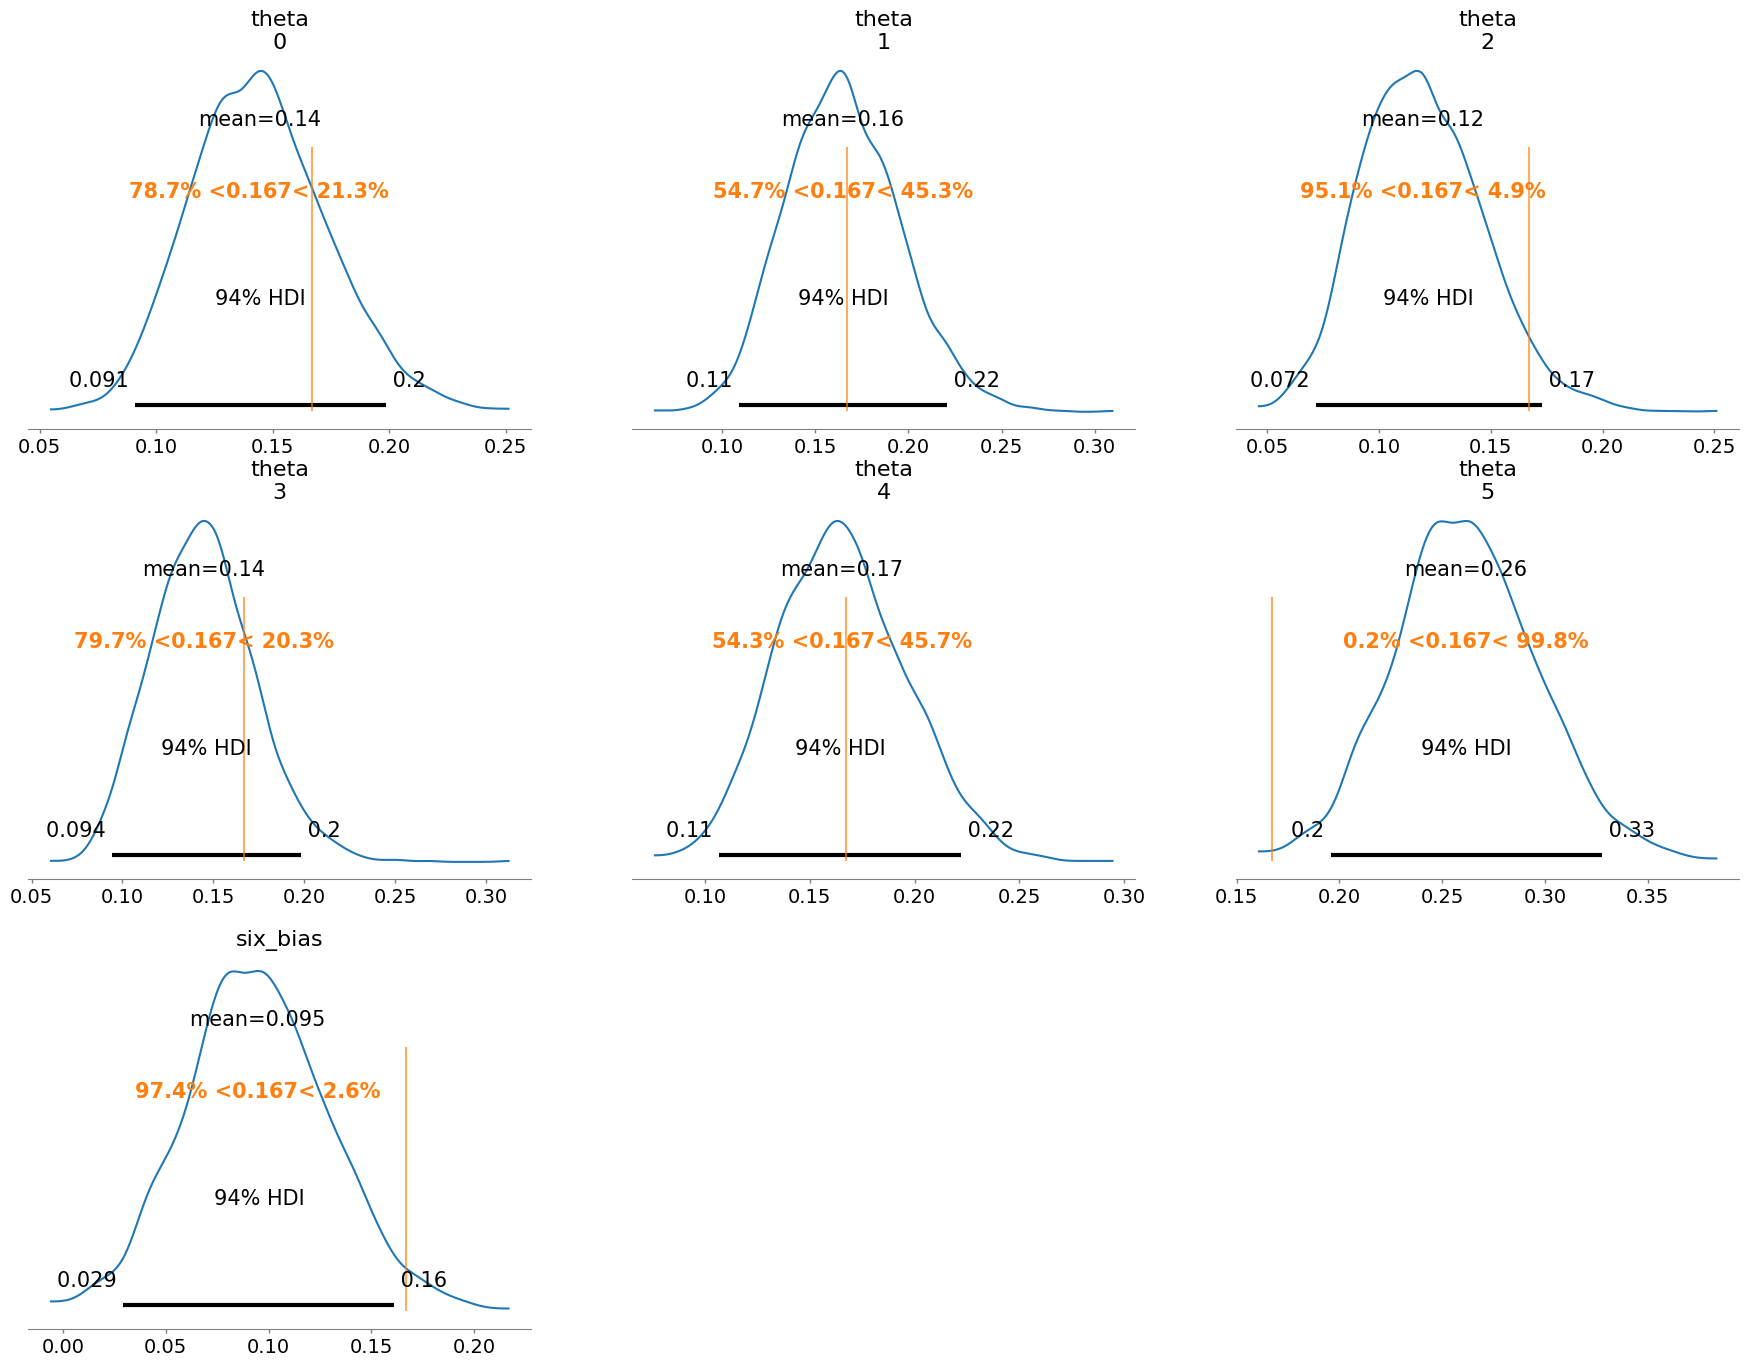

In [9]:
axes=pm.plot_posterior(dice_trace,ref_val=np.round(p,3))



La linea naranja es el promedio teórico del parámetro que corresponde a la probabilidad de tener un número entre seis, y se puede observar como el último parámetro se aleja considerablemente de ese valor indicando que la probabilidad de tener un seis  es más alta que cualquier otro número.

In [10]:
dice_trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Obteniendo el calúlo del sesgo se observa que dadas las observaciones existe un 95% de posibilidad de que el dado se encuentre sesgado hacia el número seis.

### Ejemplo votaciones

En el año 2016 se firmaba el acuerdo de paz entre el gobierno de Colombia y la guerrilla más antigua hasta ese momento conocida como las FARC. Como parte del plan de implmentación, el presidente buscó darle mayor legitimidad al proceso sometiendo los resultados de los acuerdos a votaciones entre todos los colombianos. Algunos estaban de acuerdo con el resultado y otros no. Los resultados de ese entonces se pueden observar en la siguiente tabla:


In [11]:
resultados=pd.DataFrame(data={"Votos":[6337,6441,1000]})
resultados.index=["Si","No","Blanco"]
resultados

,Votos
Si,6337
No,6441
Blanco,1000


Con esta información, se desea saber si hay una gran diferencia entre el si y el no y cuál es la  posibilidad de que en algún momento el voto del si hubiera ganado el plebicito por la paz.

In [12]:
y=np.asarray([6337,6441,1000]) ### Voto por el si, voto por el no y votos nulos
n=y.sum()
k=len(y)

with pm.Model() as plebicito_model:
    ### Se inicia con la distribución Dirichlet con una distribución prior
    a=[6*10,2*10,0.2*10]
    
    theta=pm.Dirichlet("theta",a=a)
    si_no_diff=pm.Deterministic("si_no_diff",theta[0]-theta[1])
    likelihood=pm.Multinomial("likelihood",n=n,p=theta,observed=y)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


/Users/andresmartinez/Dropbox/UExternado/EstadisticaBayesiana/Codigos/.venv/lib/python3.11/site-packages/rich/live.
py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


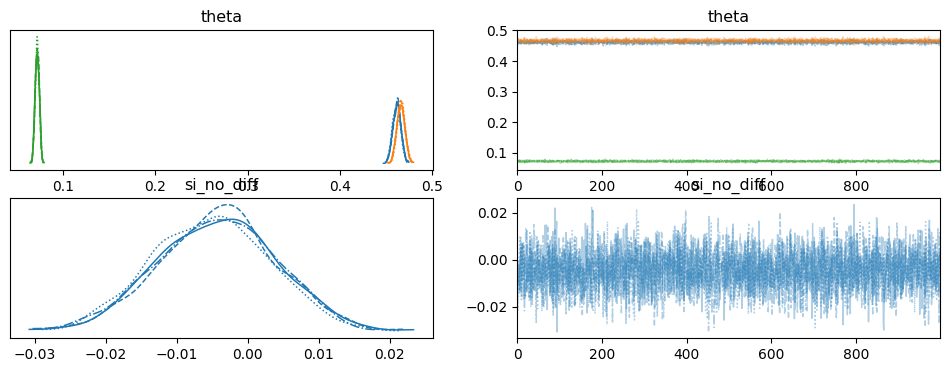

In [13]:
with plebicito_model:
    plebicito_trace=pm.sample(draws=1000)
    az.plot_trace(plebicito_trace)

In [14]:
plebicito_trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Con esta información se puede decir que el chance para que el voto del si supere al no en otro plebicito es del 18,75%.

### Segunda parte

Un segundo ejercicio tiene que ver directamente con las expectativas por resultados del plebicito antes y después de la firma del acuerdo de paz. Antes de la votación, la expectativa porque ganara el si era muy alta, no obstante, los promotores del no iniciaron una campaña buscando aumentar la posibilidad de derrotar la aceptación general del acuerdo de paz. 

Dos encuestas una antes y una después de la campaña muestran el efecto que generaron los promotores previo a la votación en el referendo.

La primera encuesta se le hizo a 500 personas y la segunda encuesta se le hizo a 670 personas los resultados se pueden ver en la siguiente tabla.

En este caso  se asume una distribución uniforme como información previa, ya que se tienen los datos de las encuestas para determinar los resultados del plebicito.

In [15]:
resultados=pd.DataFrame(data={"Primera Encuesta":[350,70,80],"Segunda Encuesta":[300,290,80] })
resultados.index=["Si","No","Blanco"]
resultados

,Primera Encuesta,Segunda Encuesta
Si,350,300
No,70,290
Blanco,80,80


In [16]:
def proportion(arr):
    arr = np.asarray(arr)
    return arr / arr.sum()


primenc_proportions = proportion([8, 2, 2])
primenc_proportions



array([0.66666667, 0.16666667, 0.16666667])

In [17]:
segenc_proportions = proportion([7, 6, 1])
segenc_proportions

array([0.5       , 0.42857143, 0.07142857])

In [ ]:
n_data_points = 10


def make_primenc_multinomial(arr):
    n_sequencing_reads = 50  # npr.poisson(lam=50)
    return npr.multinomial(n_sequencing_reads, primenc_proportions)


def make_segenc_multinomial(arr):
    n_sequencing_reads = 50  # npr.poisson(lam=50)
    return npr.multinomial(n_sequencing_reads, segenc_proportions)


# Generate healthy data
prim_reads = np.zeros((n_data_points, 3))
prim_reads = np.apply_along_axis(make_primenc_multinomial, axis=1, arr=prim_reads)

# Generate sick reads
seg_reads = np.zeros((n_data_points, 3))
seg_reads = np.apply_along_axis(make_segenc_multinomial, axis=1, arr=seg_reads)

AttributeError: module 'numpy' has no attribute 'multinomial'

Usando la información se puede crear diez escenarios  diferentes para cada encuesta que reflejen los resultados iniciales.

In [21]:
prim_df = pd.DataFrame(prim_reads)
prim_df.columns = ["SI", "NO", "Blanco"]
prim_df = pm.floatX(prim_df)
seg_df = pd.DataFrame(seg_reads)
seg_df.columns = ["SI", "NO", "Blanco"]
seg_df = pm.floatX(seg_df)
prim_df

,SI,NO,Blanco
0,36.0,5.0,9.0
1,34.0,9.0,7.0
2,37.0,8.0,5.0
3,34.0,5.0,11.0
4,37.0,8.0,5.0
5,34.0,8.0,8.0
6,37.0,6.0,7.0
7,34.0,7.0,9.0
8,33.0,11.0,6.0
9,34.0,6.0,10.0


In [22]:
seg_df

,SI,NO,Blanco
0,16.0,28.0,6.0
1,22.0,24.0,4.0
2,25.0,23.0,2.0
3,22.0,27.0,1.0
4,23.0,22.0,5.0
5,30.0,16.0,4.0
6,22.0,25.0,3.0
7,23.0,26.0,1.0
8,24.0,23.0,3.0
9,32.0,17.0,1.0


In [23]:
with pm.Model() as dirichlet_model:
    proportions_primenc = pm.Dirichlet(
        "proportions_primenc",
        a=np.array([1.0] * 3).astype("float32"),
        shape=(3,),
        testval=[0.1, 0.1, 0.1],
    )
    proportions_segenc = pm.Dirichlet(
        "proportions_segenc",
        a=np.array([1.0] * 3).astype("float32"),
        shape=(3,),
        testval=[0.1, 0.1, 0.1],
    )
    prim_like = pm.Multinomial(
        "like_prim", n=50, p=proportions_primenc, observed=prim_df.values
    )
    seg_like = pm.Multinomial(
        "like_seg", n=50, p=proportions_segenc, observed=seg_df.values
    )

/var/folders/qh/43yzjghs7pzb3lwh4m4rkxch0000gn/T/ipykernel_1187/1130473576.py:2: FutureWarning: The `testval` argument is deprecated; use `initval`.
  proportions_primenc = pm.Dirichlet(
/var/folders/qh/43yzjghs7pzb3lwh4m4rkxch0000gn/T/ipykernel_1187/1130473576.py:8: FutureWarning: The `testval` argument is deprecated; use `initval`.
  proportions_segenc = pm.Dirichlet(


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [proportions_primenc, proportions_segenc]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font family 'consolas' not found.
findfont: Font fa

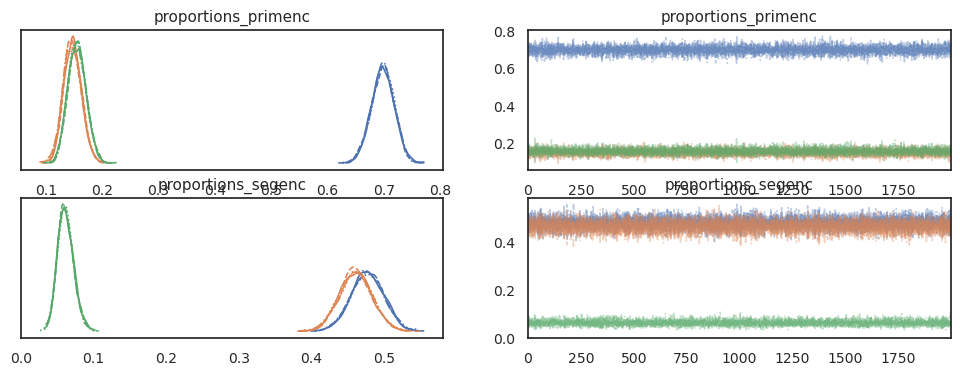

In [24]:
import arviz as az

with dirichlet_model:
    dirichlet_trace = pm.sample(2000)
    az.plot_trace(dirichlet_trace)

El resultado muestra que la campaña del no tuvo sus efectos y se acercó antes del referendo a la elección del si. El resultado fue una victoria cerrada por el no rechazando los acuerdos de paz firmandos en ese momento.

In [32]:
import numpy as np
from scipy.special import gammaln
from sklearn.metrics import confusion_matrix, classification_report

# Función para calcular la probabilidad Dirichlet-Multinomial
def dirichlet_multinomial(x, alpha):
    N = np.sum(x)
    term1 = gammaln(N + 1) - np.sum(gammaln(x + 1))
    term2 = gammaln(np.sum(alpha)) - gammaln(N + np.sum(alpha))
    term3 = np.sum(gammaln(x + alpha) - gammaln(alpha))
    return np.exp(term1 + term2 + term3)

# Definir parámetros Dirichlet para las categorías Spam y NoSpam
alpha_spam = np.array([10, 10, 10])
alpha_nospam = np.array([5, 5, 5])

# Función para simular datos
def simulate_data(num_samples, alpha_spam, alpha_nospam, word_count=5):
    X = []
    y = []
    for _ in range(num_samples):
        if np.random.rand() < 0.7:
            p = np.random.dirichlet(alpha_spam)
            label = 1  # Spam
        else:
            p = np.random.dirichlet(alpha_nospam)
            label = 0  # No Spam
        x = np.random.multinomial(word_count, p)
        X.append(x)
        y.append(label)
    return np.array(X), np.array(y)

# Simular datos
num_samples = 100
X, y_true = simulate_data(num_samples, alpha_spam, alpha_nospam)

# Clasificar los correos
y_pred = []
for x_new in X:
    prob_spam = dirichlet_multinomial(x_new, alpha_spam)
    prob_nospam = dirichlet_multinomial(x_new, alpha_nospam)
    
    posterior_spam = prob_spam / (prob_spam + prob_nospam)
    posterior_nospam = prob_nospam / (prob_spam + prob_nospam)
    
    if posterior_spam > posterior_nospam:
        y_pred.append(1)  # Spam
    else:
        y_pred.append(0)  # No Spam

y_pred = np.array(y_pred)

# Generar matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred)
print("Matriz de Confusión:")
print(conf_matrix)

# Reporte de clasificación
report = classification_report(y_true, y_pred, target_names=["No Spam", "Spam"])
print("\nReporte de Clasificación:")
print(report)


Matriz de Confusión:
[[16 11]
 [37 36]]

Reporte de Clasificación:
              precision    recall  f1-score   support

     No Spam       0.30      0.59      0.40        27
        Spam       0.77      0.49      0.60        73

    accuracy                           0.52       100
   macro avg       0.53      0.54      0.50       100
weighted avg       0.64      0.52      0.55       100



In [ ]:
### Curva AUC ROC
